In [28]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
internal_PDC_VS_MPC_dir = os.getcwd()
internal_March_30_2026_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..'))
internal_April7_2026_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..', ))
internal_April9_2026_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..', ))
print(f'The current working directory is : {internal_PDC_VS_MPC_dir}')
internal_MPC_data_dir_1 = os.path.abspath(os.path.join(internal_March_30_2026_dir, 'March30_2026'))
print(f'The MPC data directory 5kmph : {internal_MPC_data_dir_1}')
internal_MPC_data_dir_2 = os.path.abspath(os.path.join(internal_April7_2026_dir, 'April7_2026'))
print(f'The MPC data directory 10kmph : {internal_MPC_data_dir_2}')
internal_PD_data_dir = os.path.abspath(os.path.join(internal_April9_2026_dir, 'April9_2026'))
print(f'The PD data directory : {internal_PD_data_dir}')
internal_VTR_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..', '..'))
print(f'The VTR directory : {internal_VTR_dir}')
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
print(f'The root directory : {root_dir}')
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
print(f'The internal HT directory : {internal_HT_dir}')
internal_HT_MPC_dir = os.path.abspath(os.path.join(internal_HT_dir, '2_MPC_Controllers'))
print(f'The internal HT MPC directory : {internal_HT_MPC_dir}')
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_MPC_dir, 'scripts'))
print(f'The internal scripts directory : {internal_scripts_dir}')
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

The current working directory is : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\Plot_Comparisions
The MPC data directory 5kmph : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March30_2026
The MPC data directory 10kmph : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April7_2026
The PD data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April9_2026
The VTR directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results
The root directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control
The internal HT directory : c:\Users\home\Desktop\ACC\Au

In [29]:
internal_PDC_FV_data_dir = os.path.abspath(os.path.join(internal_PD_data_dir, 'Processed_Data_April9_PD'))
internal_MPC_FV_data_dir_1 = os.path.abspath(os.path.join(internal_MPC_data_dir_1, 'Processed_Data_March30_MPC'))
internal_MPC_FV_data_dir_2 = os.path.abspath(os.path.join(internal_MPC_data_dir_2, 'Processed_Data_April7_MPC'))
print(f'The PDC data directory : {internal_PDC_FV_data_dir}')
print(f'The MPC data directory : {internal_MPC_FV_data_dir_1}')
print(f'The MPC data directory : {internal_MPC_FV_data_dir_2}')

The PDC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April9_2026\Processed_Data_April9_PD
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March30_2026\Processed_Data_March30_MPC
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April7_2026\Processed_Data_April7_MPC


In [30]:
# Print the names of the files in the PDC and MPC data directories to check if they are the same
print(f'PDC data files : {os.listdir(internal_PDC_FV_data_dir)}')
print(f'MPC data files 5kmph : {os.listdir(internal_MPC_FV_data_dir_1)}')
print(f'MPC data files 10kmph : {os.listdir(internal_MPC_FV_data_dir_2)}')   

PDC data files : ['Data_Apr9_PD_10kph_FV1.csv', 'Data_Apr9_PD_10kph_FV2.csv', 'Data_Apr9_PD_10kph_FV3.csv', 'Data_Apr9_PD_10kph_FV4.csv', 'Data_Apr9_PD_10kph_FV5.csv', 'Data_Apr9_PD_5kph_FV1.csv', 'Data_Apr9_PD_5kph_FV2.csv', 'Data_Apr9_PD_5kph_FV3.csv']
MPC data files 5kmph : ['Data_Mar30_MPC_5kph_FV1.csv', 'Data_Mar30_MPC_5kph_FV2.csv', 'Data_Mar30_MPC_5kph_FV3.csv', 'Data_Mar30_MPC_5kph_FV4.csv']
MPC data files 10kmph : ['Data_Apr7_MPC_10kph_FV2.csv', 'Data_Apr7_MPC_10kph_FV3.csv', 'Data_Apr7_MPC_5kph_FV1.csv']


In [31]:
PDC_data_list = []
for i in range(len(os.listdir(internal_PDC_FV_data_dir))):
    PDC_data_list.append(pd.read_csv(os.path.join(internal_PDC_FV_data_dir, os.listdir(internal_PDC_FV_data_dir)[i])))
    
MPC_data_list = []
for i in range(len(os.listdir(internal_MPC_FV_data_dir_1))):
    MPC_data_list.append(pd.read_csv(os.path.join(internal_MPC_FV_data_dir_1, os.listdir(internal_MPC_FV_data_dir_1)[i])))

MPC_data_list_2 = []
for i in range(len(os.listdir(internal_MPC_FV_data_dir_2))):
    MPC_data_list_2.append(pd.read_csv(os.path.join(internal_MPC_FV_data_dir_2, os.listdir(internal_MPC_FV_data_dir_2)[i])))

In [32]:
# Print the column names of the first dataframe in PDC_data_list and MPC_data_list to check if they are the same
print(f'PDC data columns : {PDC_data_list[0].columns}')
print(f'MPC 5kmph data columns : {MPC_data_list[0].columns}')
print(f'MPC 10kmph data columns : {MPC_data_list_2[0].columns}')

PDC data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)',
       'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)',
       'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph',
       'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean',
       'Ego_Position_clean', 'Obs_Position_clean'],
      dtype='object')
MPC 5kmph data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)',
       'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)',
       'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph',
       'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean',
       'Ego_Position_clean', 'Obs_Position_clean

## For 5Kmph

In [33]:
# Selecting the file name for both PDC and MPC to plot them together.
PDC_file_name = os.listdir(internal_PDC_FV_data_dir)[5]    
MPC_file_name_5kmph = os.listdir(internal_MPC_FV_data_dir_1)[1]
# MPC_file_name_10kmph = os.listdir(internal_MPC_FV_data_dir_2)[0]
print(f'Selected PDC file name : {PDC_file_name}')
print(f'Selected MPC 5kmph file name : {MPC_file_name_5kmph}')
# print(f'Selected MPC 10kmph file name : {MPC_file_name_10kmph}')

Selected PDC file name : Data_Apr9_PD_5kph_FV1.csv
Selected MPC 5kmph file name : Data_Mar30_MPC_5kph_FV2.csv


PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']


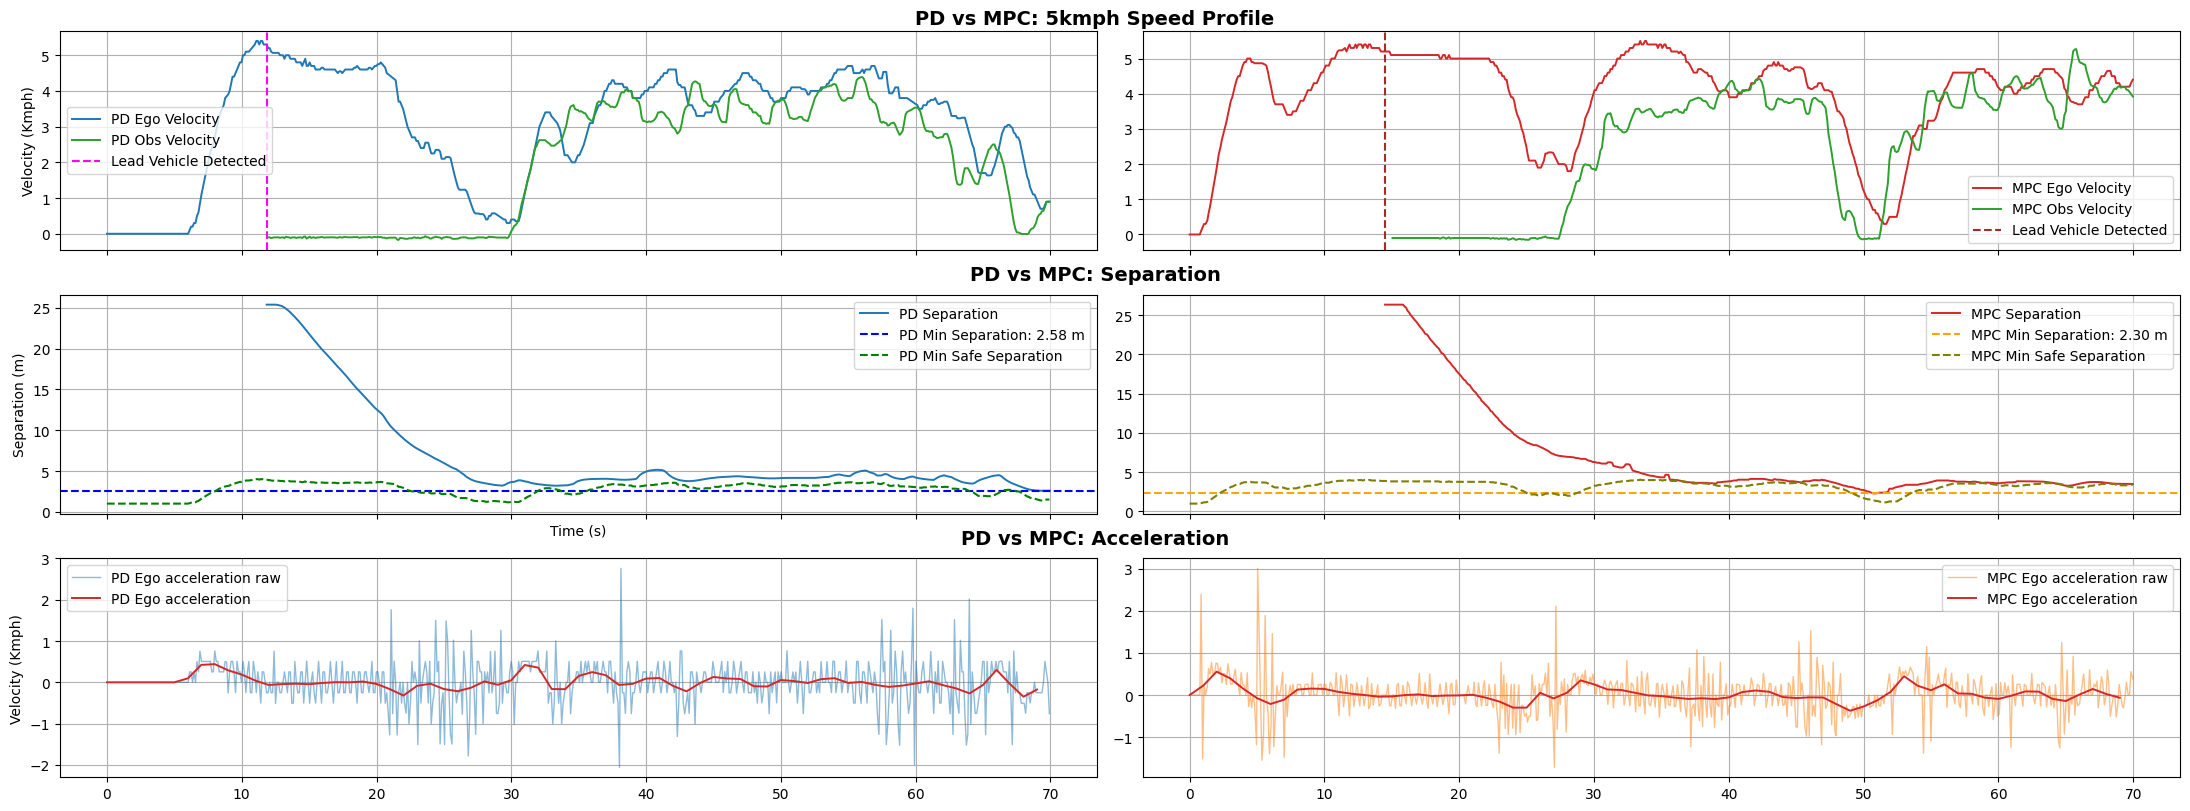

In [34]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir_1, MPC_file_name_5kmph))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
x_col_1 = "Time_1s" # Time in 1 second
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"
ego_acc_raw = "Ego_Acceleration_raw(m/s^2)"
ego_acc_clean = "Ego_Acceleration(m/s^2)"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(3, 2, figsize=(22, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0][0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0][0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:red", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][0].set_ylabel("Velocity (Kmph)")
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best")
ax[0][0].grid(True)
ax[0][1].grid(True)
# ax[0][0].set_title("PD vs MPC: 5kmph Speed Profile")

# Plot the detection line at the point where the obstacle is detected (when separation starts decreasing from a large value)
detection_time_pd = pdc_df[pdc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
detection_time_mpc = mpc_df[mpc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
ax[0][0].axvline(x=detection_time_pd, color='magenta', linestyle='--', label= 'Lead Vehicle Detected')
ax[0][1].axvline(x=detection_time_mpc, color='brown', linestyle='--', label='Lead Vehicle Detected')
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best") 


# Plot 2: Separation for PD and MPC
ax[1][0].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1][1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:red", linewidth=1.4)
ax[1][0].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1][1].axhline(y=minimum_separation_mpc, color='orange', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1][0].set_ylabel("Separation (m)")
ax[1][0].set_xlabel("Time (s)")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")
ax[1][0].grid(True)
ax[1][1].grid(True)
# ax[1][0].set_title("PD vs MPC: Separation")

# Plot 3 : Acceleration for PD and MPC
ax[2][0].plot(pdc_df[x_col], pdc_df[ego_acc_raw], label="PD Ego acceleration raw", color="tab:blue", linewidth=1, alpha=0.5)
ax[2][0].plot(pdc_df[x_col_1], pdc_df[ego_acc_clean], label="PD Ego acceleration ", color="tab:red", linewidth=1.4)
ax[2][1].plot(mpc_df[x_col], mpc_df[ego_acc_raw], label="MPC Ego acceleration raw", color="tab:orange", linewidth=1 , alpha=0.5)
ax[2][1].plot(mpc_df[x_col_1], mpc_df[ego_acc_clean], label="MPC Ego acceleration", color="tab:red", linewidth=1.4)
ax[2][0].set_ylabel("Velocity (Kmph)")
ax[2][0].legend(loc="best")
ax[2][1].legend(loc="best")
ax[2][0].grid(True)
ax[2][1].grid(True)

fig.subplots_adjust(hspace=1)  # Reasonable spacing between rows
plt.tight_layout()

fig.text(0.5, 0.99, "PD vs MPC: 5kmph Speed Profile", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.67, "PD vs MPC: Separation", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.34, "PD vs MPC: Acceleration", ha='center', fontsize=14, weight='bold')

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1][0].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1][1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")


plt.tight_layout()
plt.show() 

## 10 Kmph

In [35]:
# Selecting the file name for both PDC and MPC to plot them together.
PDC_file_name = os.listdir(internal_PDC_FV_data_dir)[0]    
MPC_file_name_10kmph = os.listdir(internal_MPC_FV_data_dir_2)[0]
print(f'Selected PDC file name : {PDC_file_name}')
print(f'Selected MPC 10kmph file name : {MPC_file_name_10kmph}')

Selected PDC file name : Data_Apr9_PD_10kph_FV1.csv
Selected MPC 10kmph file name : Data_Apr7_MPC_10kph_FV2.csv


PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Throttle_command', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']


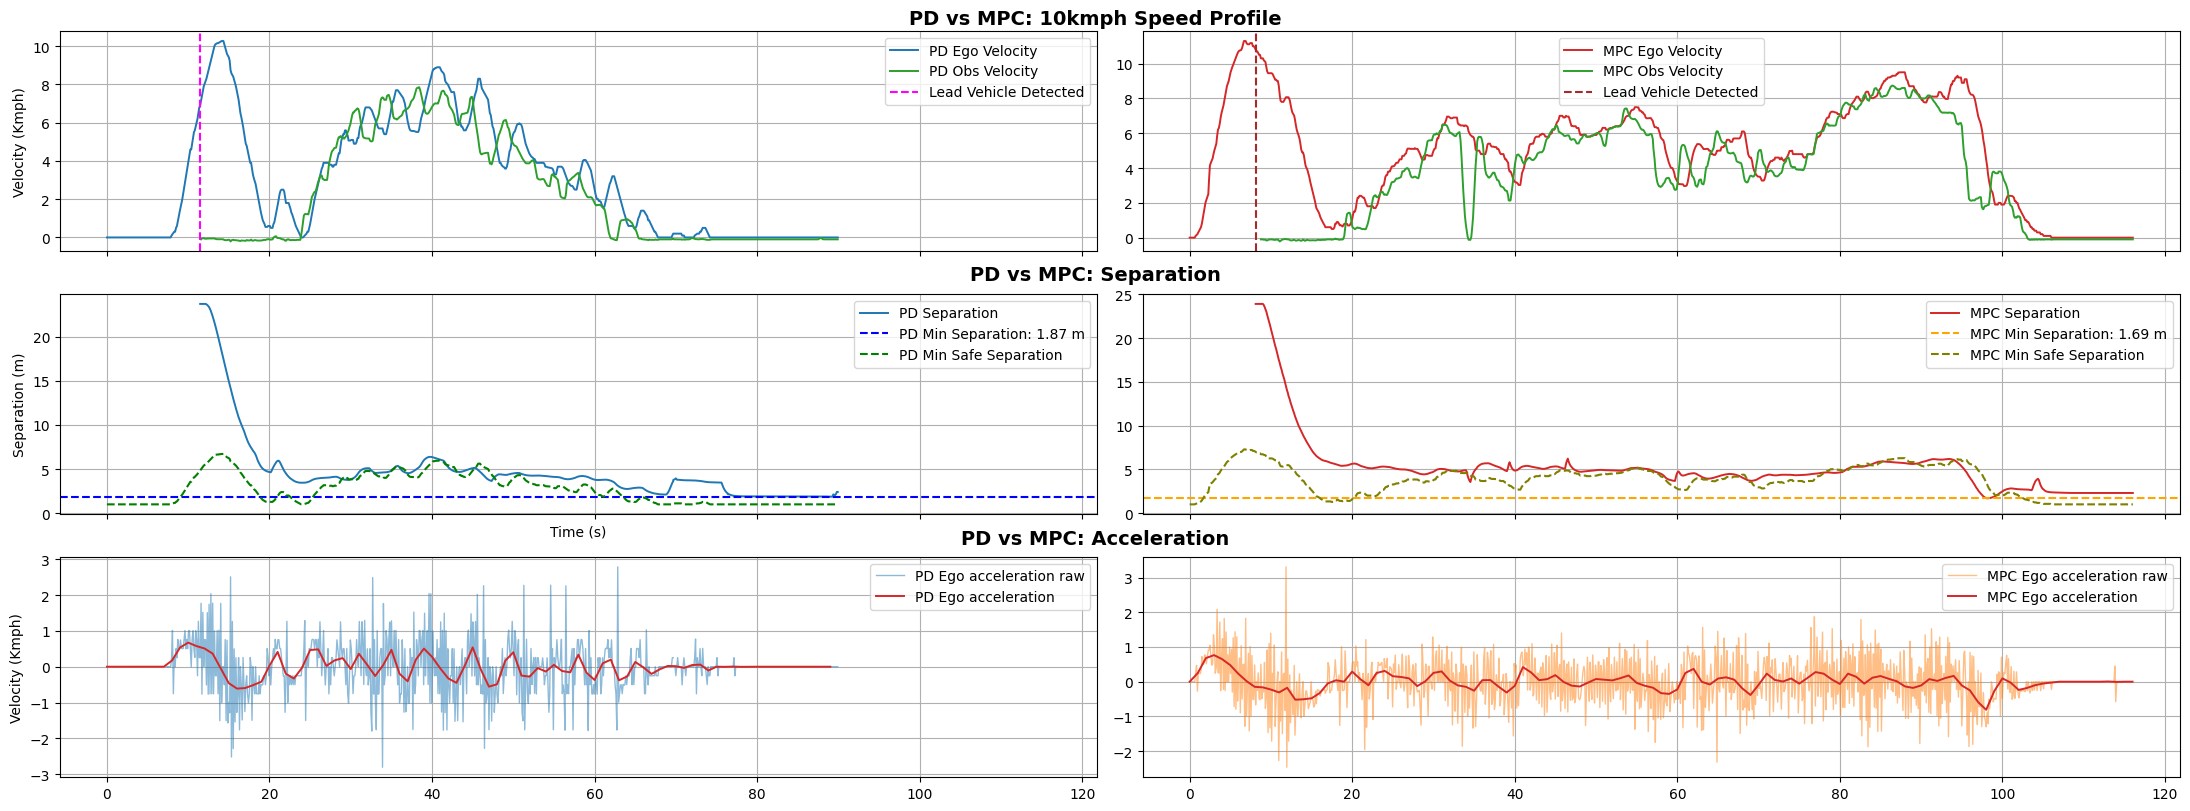

In [36]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir_2, MPC_file_name_10kmph))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
x_col_1 = "Time_1s" # Time in 1 second
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"
ego_acc_raw = "Ego_Acceleration_raw(m/s^2)"
ego_acc_clean = "Ego_Acceleration(m/s^2)"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(3, 2, figsize=(22, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0][0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0][0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:red", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][0].set_ylabel("Velocity (Kmph)")
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best")
ax[0][0].grid(True)
ax[0][1].grid(True)
# ax[0][0].set_title("PD vs MPC: 10kmph Speed Profile")

# Plot the detection line at the point where the obstacle is detected (when separation starts decreasing from a large value)
detection_time_pd = pdc_df[pdc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
detection_time_mpc = mpc_df[mpc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
ax[0][0].axvline(x=detection_time_pd, color='magenta', linestyle='--', label= 'Lead Vehicle Detected')
ax[0][1].axvline(x=detection_time_mpc, color='brown', linestyle='--', label='Lead Vehicle Detected')
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best") 

# Plot 2: Separation for PD and MPC
ax[1][0].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1][1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:red", linewidth=1.4)
ax[1][0].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1][1].axhline(y=minimum_separation_mpc, color='orange', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1][0].set_ylabel("Separation (m)")
ax[1][0].set_xlabel("Time (s)")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")
ax[1][0].grid(True)
ax[1][1].grid(True)
# ax[1][0].set_title("PD vs MPC: Separation")

# Plot 3 : Acceleration for PD and MPC
ax[2][0].plot(pdc_df[x_col], pdc_df[ego_acc_raw], label="PD Ego acceleration raw", color="tab:blue", linewidth=1, alpha=0.5)
ax[2][0].plot(pdc_df[x_col_1], pdc_df[ego_acc_clean], label="PD Ego acceleration ", color="tab:red", linewidth=1.4)
ax[2][1].plot(mpc_df[x_col], mpc_df[ego_acc_raw], label="MPC Ego acceleration raw", color="tab:orange", linewidth=1 , alpha=0.5)
ax[2][1].plot(mpc_df[x_col_1], mpc_df[ego_acc_clean], label="MPC Ego acceleration", color="tab:red", linewidth=1.4)
ax[2][0].set_ylabel("Velocity (Kmph)")
ax[2][0].legend(loc="best")
ax[2][1].legend(loc="best")
ax[2][0].grid(True)
ax[2][1].grid(True)

fig.subplots_adjust(hspace=1)  # Reasonable spacing between rows
plt.tight_layout()

fig.text(0.5, 0.99, "PD vs MPC: 10kmph Speed Profile", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.67, "PD vs MPC: Separation", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.34, "PD vs MPC: Acceleration", ha='center', fontsize=14, weight='bold')

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1][0].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1][1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")


plt.tight_layout()
plt.show() 

# Metrics Analysis & Visualization: FV Testing Campaign

In [37]:
import numpy as np
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

def calculate_metrics_fv(df, controller_name="Controller"):
    sep_col = "Separation_clean"
    ego_vel_col = "Ego_Velocity_clean"
    obs_vel_col = "Obs_Velocity_clean"
    ego_acc_raw = "Ego_Acceleration_raw(m/s^2)"
    ego_acc_clean = "Ego_Acceleration(m/s^2)"
    time_col = "Time(s)"

    min_sep = df[sep_col].min()
    mean_sep = df[sep_col].mean()
    std_sep = df[sep_col].std()

    rms_acc = np.sqrt(np.mean(df[ego_acc_clean]**2))

    acc_smooth = df[ego_acc_clean].values
    dt = np.diff(df[time_col].values)
    dt = np.median(dt[dt > 0])
    jerk = np.diff(acc_smooth) / dt
    mean_jerk = np.mean(np.abs(jerk))
    max_jerk = np.max(np.abs(jerk))

    ego_vel = df[ego_vel_col].values
    obs_vel = df[obs_vel_col].values
    vel_error = ego_vel - obs_vel

    overshoot_idx = vel_error > 0
    if np.sum(overshoot_idx) > 0:
        overshoot_pct = (vel_error[overshoot_idx] / (obs_vel[overshoot_idx] + 1e-6)) * 100
        max_overshoot_pct = np.max(overshoot_pct)
        mean_overshoot_pct = np.mean(overshoot_pct)
    else:
        max_overshoot_pct = 0
        mean_overshoot_pct = 0

    undershoot_idx = vel_error < 0
    if np.sum(undershoot_idx) > 0:
        undershoot_pct = (np.abs(vel_error[undershoot_idx]) / (obs_vel[undershoot_idx] + 1e-6)) * 100
        max_undershoot_pct = np.max(undershoot_pct)
        mean_undershoot_pct = np.mean(undershoot_pct)
    else:
        max_undershoot_pct = 0
        mean_undershoot_pct = 0

    return {
        'Controller': controller_name,
        'Min Separation (m)': f"{min_sep:.3f}",
        'Mean Separation (m)': f"{mean_sep:.3f}",
        'Std Separation (m)': f"{std_sep:.3f}",
        'RMS Acceleration (m/s^2)': f"{rms_acc:.4f}",
        'Mean Jerk (m/s^3)': f"{mean_jerk:.4f}",
        'Max Jerk (m/s^3)': f"{max_jerk:.4f}",
        'Max Overshoot (%)': f"{max_overshoot_pct:.2f}",
        'Mean Overshoot (%)': f"{mean_overshoot_pct:.2f}",
        'Max Undershoot (%)': f"{max_undershoot_pct:.2f}",
        'Mean Undershoot (%)': f"{mean_undershoot_pct:.2f}",
    }

# Calculate metrics for all FV files
all_metrics_fv = []

# 5 kph metrics
for pd_file in sorted(os.listdir(internal_PDC_FV_data_dir)):
    if '5kph' in pd_file:
        pd_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, pd_file))
        all_metrics_fv.append(calculate_metrics_fv(pd_df, f"PD-{pd_file.split('_')[3]}"))

for mpc_file in sorted(os.listdir(internal_MPC_FV_data_dir_1)):
    if '5kph' in mpc_file:
        mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir_1, mpc_file))
        all_metrics_fv.append(calculate_metrics_fv(mpc_df, f"MPC-{mpc_file.split('_')[3]}"))

# 10 kph metrics
for pd_file in sorted(os.listdir(internal_PDC_FV_data_dir)):
    if '10kph' in pd_file:
        pd_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, pd_file))
        all_metrics_fv.append(calculate_metrics_fv(pd_df, f"PD-{pd_file.split('_')[3]}"))

for mpc_file in sorted(os.listdir(internal_MPC_FV_data_dir_2)):
    if '10kph' in mpc_file:
        mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir_2, mpc_file))
        all_metrics_fv.append(calculate_metrics_fv(mpc_df, f"MPC-{mpc_file.split('_')[3]}"))

metrics_fv_df = pd.DataFrame(all_metrics_fv)
print(f"Calculated metrics for {len(all_metrics_fv)} FV test cases")
print("\nMetrics Summary:")
print(metrics_fv_df.to_string(index=False))

metrics_fv_df.to_csv('FV_Metrics_Comparison.csv', index=False)
print("\nMetrics saved to: FV_Metrics_Comparison.csv")


Calculated metrics for 14 FV test cases

Metrics Summary:
Controller Min Separation (m) Mean Separation (m) Std Separation (m) RMS Acceleration (m/s^2) Mean Jerk (m/s^3) Max Jerk (m/s^3) Max Overshoot (%) Mean Overshoot (%) Max Undershoot (%) Mean Undershoot (%)
   PD-5kph              2.582               6.672              5.794                   0.1644            0.1157           4.7148          15111.27           -2698.48              44.49               16.10
   PD-5kph              0.944               7.740              7.710                   0.1648            0.1100           3.8448           2226.19           -1165.62              81.12               14.38
   PD-5kph             -9.367               1.610              7.169                   0.1482            0.0868           3.1144           5562.16            -482.07              35.25               12.60
  MPC-5kph              1.318               6.959              7.230                   0.1391            0.0546           

In [38]:
import seaborn as sns
sns.set_style("whitegrid")

# Prepare numeric metrics for FV visualization
all_metrics_numeric_fv = []

# 5 kph
for pd_file in sorted(os.listdir(internal_PDC_FV_data_dir)):
    if '5kph' in pd_file:
        pd_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, pd_file))
        sep_col, ego_vel_col, obs_vel_col = "Separation_clean", "Ego_Velocity_clean", "Obs_Velocity_clean"
        ego_acc_clean, time_col = "Ego_Acceleration(m/s^2)", "Time(s)"

        min_sep = pd_df[sep_col].min()
        rms_acc = np.sqrt(np.mean(pd_df[ego_acc_clean]**2))
        acc_smooth = pd_df[ego_acc_clean].values
        dt = np.median(np.diff(pd_df[time_col].values))
        mean_jerk = np.mean(np.abs(np.diff(acc_smooth) / dt))

        ego_vel = pd_df[ego_vel_col].values
        obs_vel = pd_df[obs_vel_col].values
        vel_error = ego_vel - obs_vel

        overshoot_idx = vel_error > 0
        max_overshoot = np.max((vel_error[overshoot_idx] / (obs_vel[overshoot_idx] + 1e-6)) * 100) if np.sum(overshoot_idx) > 0 else 0

        undershoot_idx = vel_error < 0
        max_undershoot = np.max((np.abs(vel_error[undershoot_idx]) / (obs_vel[undershoot_idx] + 1e-6)) * 100) if np.sum(undershoot_idx) > 0 else 0

        all_metrics_numeric_fv.append({
            'Speed': '5kph',
            'Type': 'PD',
            'Test': pd_file.split('_')[3],
            'Min Separation': min_sep,
            'RMS Acceleration': rms_acc,
            'Mean Jerk': mean_jerk,
            'Max Overshoot': max_overshoot,
            'Max Undershoot': max_undershoot,
        })

for mpc_file in sorted(os.listdir(internal_MPC_FV_data_dir_1)):
    if '5kph' in mpc_file:
        mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir_1, mpc_file))
        sep_col, ego_vel_col, obs_vel_col = "Separation_clean", "Ego_Velocity_clean", "Obs_Velocity_clean"
        ego_acc_clean, time_col = "Ego_Acceleration(m/s^2)", "Time(s)"

        min_sep = mpc_df[sep_col].min()
        rms_acc = np.sqrt(np.mean(mpc_df[ego_acc_clean]**2))
        acc_smooth = mpc_df[ego_acc_clean].values
        dt = np.median(np.diff(mpc_df[time_col].values))
        mean_jerk = np.mean(np.abs(np.diff(acc_smooth) / dt))

        ego_vel = mpc_df[ego_vel_col].values
        obs_vel = mpc_df[obs_vel_col].values
        vel_error = ego_vel - obs_vel

        overshoot_idx = vel_error > 0
        max_overshoot = np.max((vel_error[overshoot_idx] / (obs_vel[overshoot_idx] + 1e-6)) * 100) if np.sum(overshoot_idx) > 0 else 0

        undershoot_idx = vel_error < 0
        max_undershoot = np.max((np.abs(vel_error[undershoot_idx]) / (obs_vel[undershoot_idx] + 1e-6)) * 100) if np.sum(undershoot_idx) > 0 else 0

        all_metrics_numeric_fv.append({
            'Speed': '5kph',
            'Type': 'MPC',
            'Test': mpc_file.split('_')[3],
            'Min Separation': min_sep,
            'RMS Acceleration': rms_acc,
            'Mean Jerk': mean_jerk,
            'Max Overshoot': max_overshoot,
            'Max Undershoot': max_undershoot,
        })

# 10 kph
for pd_file in sorted(os.listdir(internal_PDC_FV_data_dir)):
    if '10kph' in pd_file:
        pd_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, pd_file))
        sep_col, ego_vel_col, obs_vel_col = "Separation_clean", "Ego_Velocity_clean", "Obs_Velocity_clean"
        ego_acc_clean, time_col = "Ego_Acceleration(m/s^2)", "Time(s)"

        min_sep = pd_df[sep_col].min()
        rms_acc = np.sqrt(np.mean(pd_df[ego_acc_clean]**2))
        acc_smooth = pd_df[ego_acc_clean].values
        dt = np.median(np.diff(pd_df[time_col].values))
        mean_jerk = np.mean(np.abs(np.diff(acc_smooth) / dt))

        ego_vel = pd_df[ego_vel_col].values
        obs_vel = pd_df[obs_vel_col].values
        vel_error = ego_vel - obs_vel

        overshoot_idx = vel_error > 0
        max_overshoot = np.max((vel_error[overshoot_idx] / (obs_vel[overshoot_idx] + 1e-6)) * 100) if np.sum(overshoot_idx) > 0 else 0

        undershoot_idx = vel_error < 0
        max_undershoot = np.max((np.abs(vel_error[undershoot_idx]) / (obs_vel[undershoot_idx] + 1e-6)) * 100) if np.sum(undershoot_idx) > 0 else 0

        all_metrics_numeric_fv.append({
            'Speed': '10kph',
            'Type': 'PD',
            'Test': pd_file.split('_')[3],
            'Min Separation': min_sep,
            'RMS Acceleration': rms_acc,
            'Mean Jerk': mean_jerk,
            'Max Overshoot': max_overshoot,
            'Max Undershoot': max_undershoot,
        })

for mpc_file in sorted(os.listdir(internal_MPC_FV_data_dir_2)):
    if '10kph' in mpc_file:
        mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir_2, mpc_file))
        sep_col, ego_vel_col, obs_vel_col = "Separation_clean", "Ego_Velocity_clean", "Obs_Velocity_clean"
        ego_acc_clean, time_col = "Ego_Acceleration(m/s^2)", "Time(s)"

        min_sep = mpc_df[sep_col].min()
        rms_acc = np.sqrt(np.mean(mpc_df[ego_acc_clean]**2))
        acc_smooth = mpc_df[ego_acc_clean].values
        dt = np.median(np.diff(mpc_df[time_col].values))
        mean_jerk = np.mean(np.abs(np.diff(acc_smooth) / dt))

        ego_vel = mpc_df[ego_vel_col].values
        obs_vel = mpc_df[obs_vel_col].values
        vel_error = ego_vel - obs_vel

        overshoot_idx = vel_error > 0
        max_overshoot = np.max((vel_error[overshoot_idx] / (obs_vel[overshoot_idx] + 1e-6)) * 100) if np.sum(overshoot_idx) > 0 else 0

        undershoot_idx = vel_error < 0
        max_undershoot = np.max((np.abs(vel_error[undershoot_idx]) / (obs_vel[undershoot_idx] + 1e-6)) * 100) if np.sum(undershoot_idx) > 0 else 0

        all_metrics_numeric_fv.append({
            'Speed': '10kph',
            'Type': 'MPC',
            'Test': mpc_file.split('_')[3],
            'Min Separation': min_sep,
            'RMS Acceleration': rms_acc,
            'Mean Jerk': mean_jerk,
            'Max Overshoot': max_overshoot,
            'Max Undershoot': max_undershoot,
        })

metrics_plot_fv_df = pd.DataFrame(all_metrics_numeric_fv)
print(f"Prepared {len(metrics_plot_fv_df)} FV records for visualization")


Prepared 14 FV records for visualization


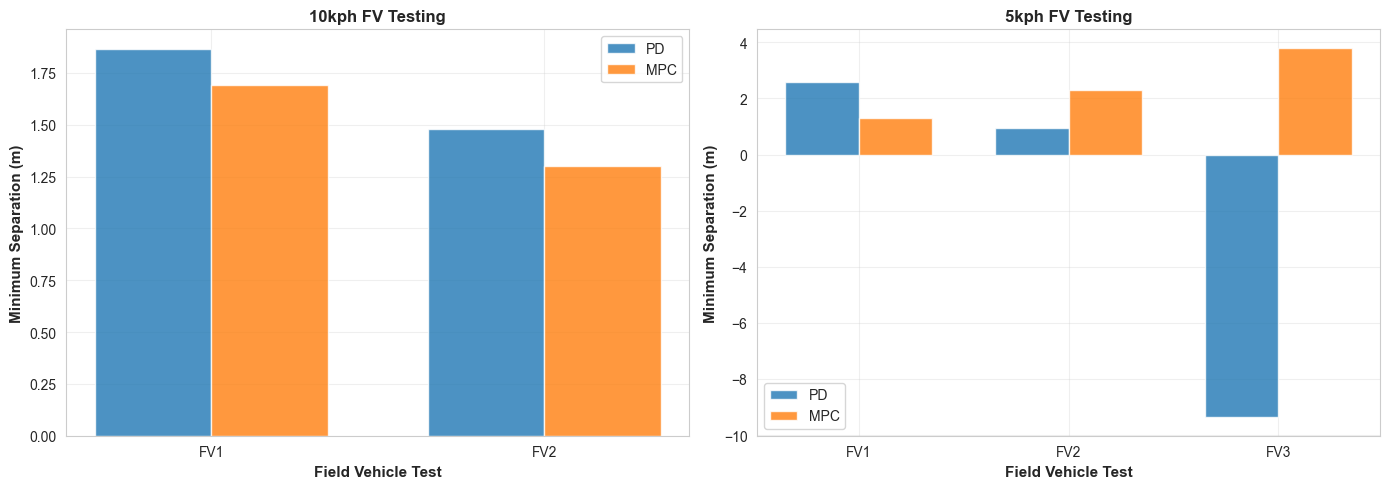

FV Plot 1: Separation Comparison - Complete


In [39]:
# FV PLOT 1: Separation Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, speed in enumerate(sorted(metrics_plot_fv_df['Speed'].unique())):
    speed_data = metrics_plot_fv_df[metrics_plot_fv_df['Speed'] == speed]
    pd_data = speed_data[speed_data['Type'] == 'PD'].sort_values('Test')
    mpc_data = speed_data[speed_data['Type'] == 'MPC'].sort_values('Test')

    # Use min count for bar alignment
    n_tests = min(len(pd_data), len(mpc_data))
    x = np.arange(n_tests)
    width = 0.35

    axes[idx].bar(x - width/2, pd_data['Min Separation'].values[:n_tests], width, label='PD', alpha=0.8, color='#1f77b4')
    axes[idx].bar(x + width/2, mpc_data['Min Separation'].values[:n_tests], width, label='MPC', alpha=0.8, color='#ff7f0e')

    axes[idx].set_xlabel('Field Vehicle Test', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Minimum Separation (m)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{speed} FV Testing', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([f"FV{i+1}" for i in range(n_tests)])
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("FV Plot 1: Separation Comparison - Complete")


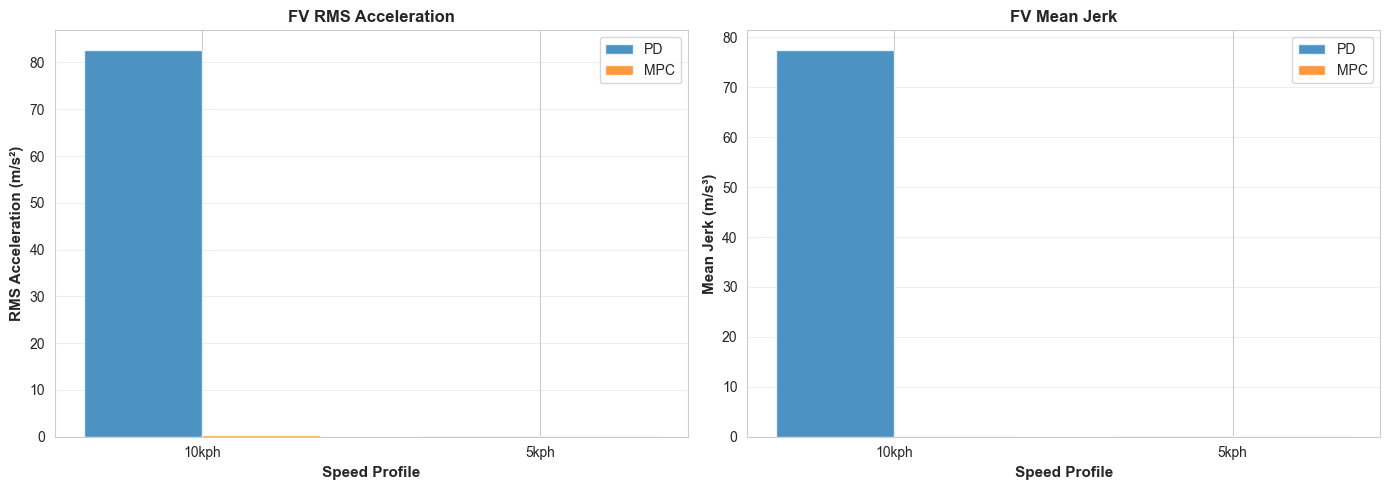

FV Plot 2: Smoothness Metrics - Complete


In [40]:
# FV PLOT 2: Smoothness Metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, metric in enumerate(['RMS Acceleration', 'Mean Jerk']):
    speed_groups = sorted(metrics_plot_fv_df['Speed'].unique())
    pd_means = [metrics_plot_fv_df[(metrics_plot_fv_df['Speed'] == speed) & (metrics_plot_fv_df['Type'] == 'PD')][metric].mean() for speed in speed_groups]
    mpc_means = [metrics_plot_fv_df[(metrics_plot_fv_df['Speed'] == speed) & (metrics_plot_fv_df['Type'] == 'MPC')][metric].mean() for speed in speed_groups]

    x = np.arange(len(speed_groups))
    width = 0.35

    axes[idx].bar(x - width/2, pd_means, width, label='PD', alpha=0.8, color='#1f77b4')
    axes[idx].bar(x + width/2, mpc_means, width, label='MPC', alpha=0.8, color='#ff7f0e')

    axes[idx].set_xlabel('Speed Profile', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(metric + (' (m/s²)' if 'Accel' in metric else ' (m/s³)'), fontsize=11, fontweight='bold')
    axes[idx].set_title(f'FV {metric}', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(speed_groups)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("FV Plot 2: Smoothness Metrics - Complete")


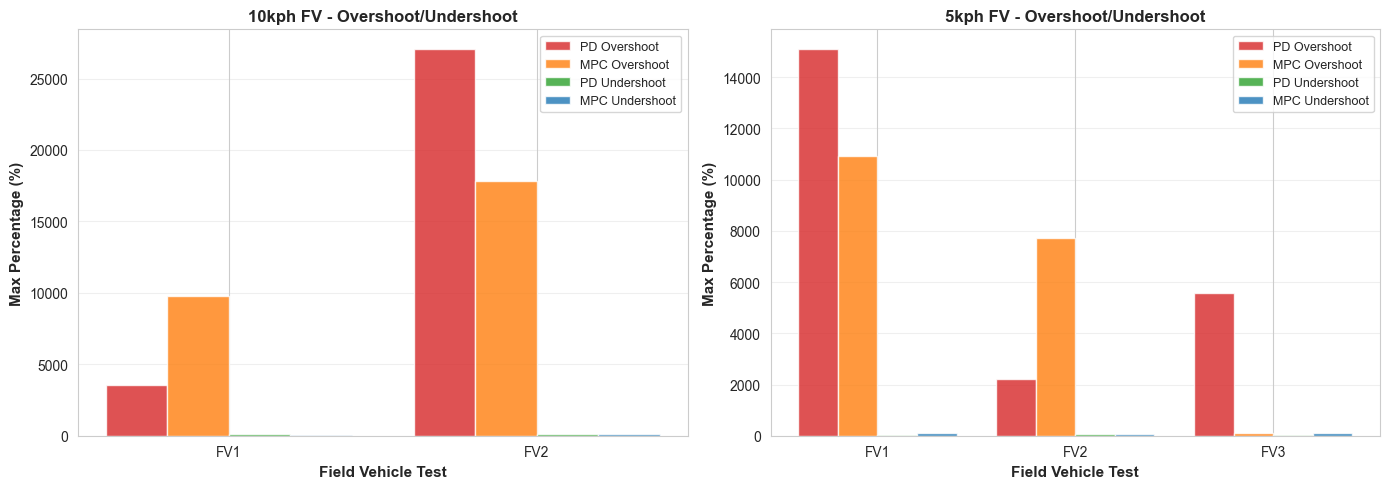

FV Plot 3: Overshoot/Undershoot - Complete


In [41]:
# FV PLOT 3: Overshoot/Undershoot Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, speed in enumerate(sorted(metrics_plot_fv_df['Speed'].unique())):
    speed_data = metrics_plot_fv_df[metrics_plot_fv_df['Speed'] == speed]
    pd_data = speed_data[speed_data['Type'] == 'PD'].sort_values('Test')
    mpc_data = speed_data[speed_data['Type'] == 'MPC'].sort_values('Test')

    n_tests = min(len(pd_data), len(mpc_data))
    x = np.arange(n_tests)
    width = 0.2

    axes[idx].bar(x - width*1.5, pd_data['Max Overshoot'].values[:n_tests], width, label='PD Overshoot', alpha=0.8, color='#d62728')
    axes[idx].bar(x - width*0.5, mpc_data['Max Overshoot'].values[:n_tests], width, label='MPC Overshoot', alpha=0.8, color='#ff7f0e')
    axes[idx].bar(x + width*0.5, pd_data['Max Undershoot'].values[:n_tests], width, label='PD Undershoot', alpha=0.8, color='#2ca02c')
    axes[idx].bar(x + width*1.5, mpc_data['Max Undershoot'].values[:n_tests], width, label='MPC Undershoot', alpha=0.8, color='#1f77b4')

    axes[idx].set_xlabel('Field Vehicle Test', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Max Percentage (%)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{speed} FV - Overshoot/Undershoot', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([f"FV{i+1}" for i in range(n_tests)])
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("FV Plot 3: Overshoot/Undershoot - Complete")


In [42]:
# FV Summary Statistics
print("="*80)
print("FV TESTING: MPC vs PD PERFORMANCE SUMMARY")
print("="*80)

for speed in sorted(metrics_plot_fv_df['Speed'].unique()):
    speed_data = metrics_plot_fv_df[metrics_plot_fv_df['Speed'] == speed]

    print(f"\n{speed} Speed Profile:")
    print("-" * 60)

    pd_avg_sep = speed_data[speed_data['Type'] == 'PD']['Min Separation'].mean()
    mpc_avg_sep = speed_data[speed_data['Type'] == 'MPC']['Min Separation'].mean()
    sep_improvement = ((mpc_avg_sep - pd_avg_sep) / pd_avg_sep) * 100

    pd_avg_acc = speed_data[speed_data['Type'] == 'PD']['RMS Acceleration'].mean()
    mpc_avg_acc = speed_data[speed_data['Type'] == 'MPC']['RMS Acceleration'].mean()
    acc_improvement = ((pd_avg_acc - mpc_avg_acc) / pd_avg_acc) * 100

    pd_avg_jerk = speed_data[speed_data['Type'] == 'PD']['Mean Jerk'].mean()
    mpc_avg_jerk = speed_data[speed_data['Type'] == 'MPC']['Mean Jerk'].mean()
    jerk_improvement = ((pd_avg_jerk - mpc_avg_jerk) / pd_avg_jerk) * 100

    print(f"Min Separation: PD {pd_avg_sep:.2f}m vs MPC {mpc_avg_sep:.2f}m ({sep_improvement:+.1f}%)")
    print(f"RMS Acceleration: PD {pd_avg_acc:.4f} vs MPC {mpc_avg_acc:.4f} ({acc_improvement:+.1f}%)")
    print(f"Mean Jerk: PD {pd_avg_jerk:.4f} vs MPC {mpc_avg_jerk:.4f} ({jerk_improvement:+.1f}%)")

print("\n" + "="*80)
print("FV Field Vehicle Analysis Complete!")
print("="*80)


FV TESTING: MPC vs PD PERFORMANCE SUMMARY

10kph Speed Profile:
------------------------------------------------------------
Min Separation: PD 1.49m vs MPC 1.50m (+0.5%)
RMS Acceleration: PD 82.7338 vs MPC 0.2754 (+99.7%)
Mean Jerk: PD 77.5188 vs MPC 0.1444 (+99.8%)

5kph Speed Profile:
------------------------------------------------------------
Min Separation: PD -1.95m vs MPC 2.50m (-228.6%)
RMS Acceleration: PD 0.1591 vs MPC 0.1515 (+4.8%)
Mean Jerk: PD 0.1042 vs MPC 0.0737 (+29.2%)

FV Field Vehicle Analysis Complete!
